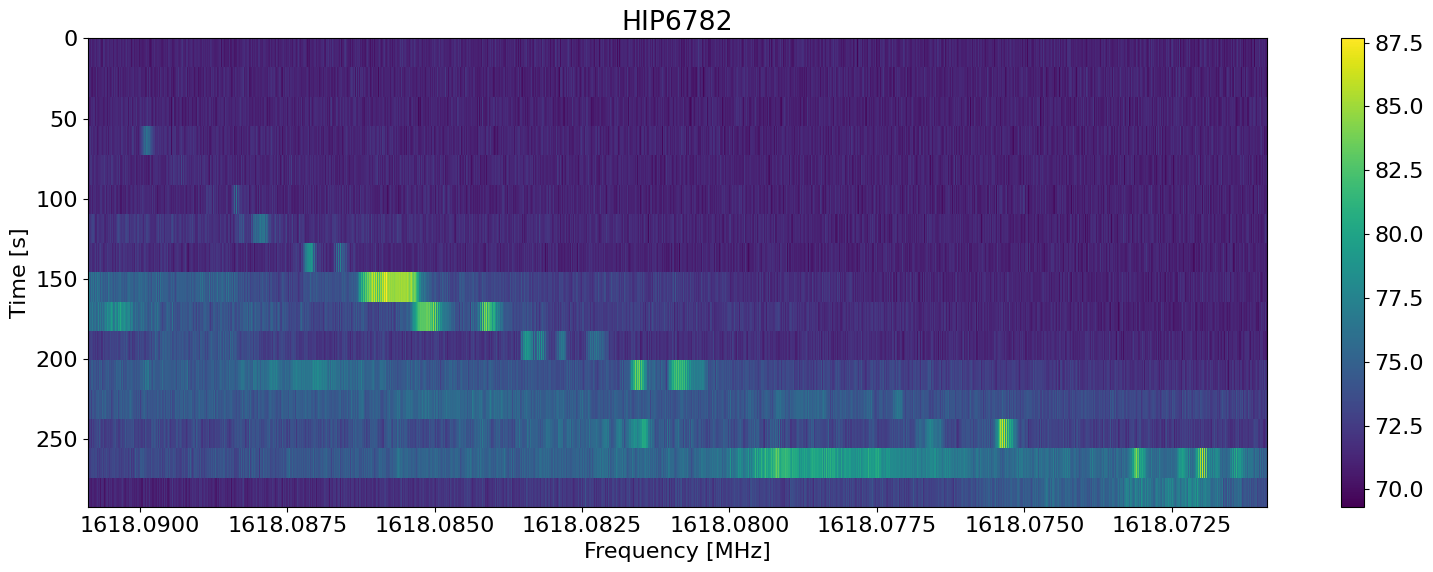

In [45]:
%matplotlib inline

from blimpy import Waterfall
import matplotlib.pyplot as plt

filename = "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_23051_HIP6782_0093.rawspec.0000.h5"

center = 1618.080878
span = 0.01   # +/- 10 kHz

wf = Waterfall(
    filename,
    f_start=center - span,
    f_stop=center + span,
)

# Close any old figures
plt.close("all")

# Let blimpy make the plot
wf.plot_waterfall()

# Grab the figure and axes that blimpy just created
fig = plt.gcf()
ax = plt.gca()

# Resize the figure
fig.set_size_inches(16, 6)

# Match the CARMENES convention
ax.invert_xaxis()      # Frequency increases to the left
ax.invert_yaxis()      # Time increases downward

# Make labels easier to read
fig.tight_layout()

# Save
fig.savefig("waterfall_plot.png", dpi=300)

plt.show()

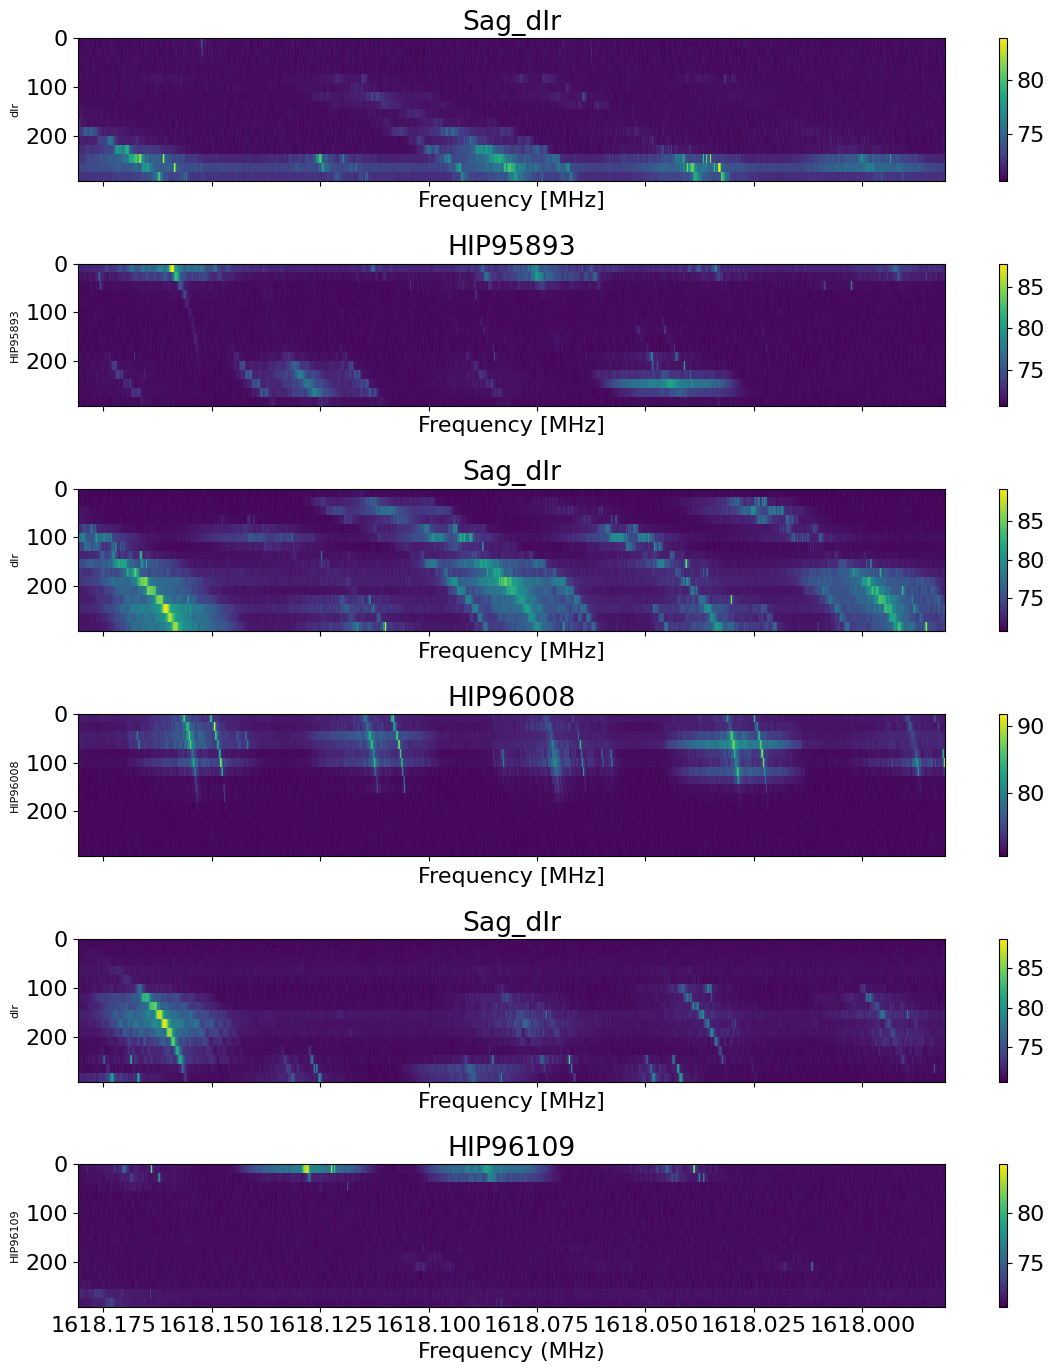

In [46]:
%matplotlib inline

from blimpy import Waterfall
import matplotlib.pyplot as plt
from pathlib import Path

files = [
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000.h5",
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000.h5",
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000.h5",
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000.h5",
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000.h5",
"/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000.h5",
]

center = 1618.080878
span = 0.1   # MHz on each side

fig, axes = plt.subplots(
    len(files),
    1,
    figsize=(12, 14),
    sharex=True
)

if len(files) == 1:
    axes = [axes]


for ax, filename in zip(axes, files):

    wf = Waterfall(
        filename,
        f_start=center-span,
        f_stop=center+span,
    )

    # Make blimpy use this subplot
    plt.sca(ax)

    wf.plot_waterfall()

    # Steve's convention:
    # time increases downward
    # frequency increases toward the left
    ax.invert_yaxis()
    ax.invert_xaxis()

    # cleaner labels
    label = Path(filename).stem.split("_")[-2]
    ax.set_ylabel(label, fontsize=8)


axes[-1].set_xlabel("Frequency (MHz)")

plt.tight_layout()

plt.savefig(
    "cadence_waterfall_flipped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
from pathlib import Path

for f in h5_files:
    print(Path(f).exists(), f)

False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000/blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000.h5
False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000/blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000.h5
False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000/blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000.h5
False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000/blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000.h5
False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000/blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000.h5
False /home/obs/turboseti/AGBT21A_996_46/blc03/blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000/blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000.h5


In [51]:
from blimpy import Waterfall
import matplotlib.pyplot as plt
from pathlib import Path


def plot_cadence_frequency(files, center, span=0.1, outfile=None):

    fig, axes = plt.subplots(
        len(files),
        1,
        figsize=(12, 14),
        sharex=True
    )

    if len(files) == 1:
        axes = [axes]

    for ax, filename in zip(axes, files):

        print(f"Plotting {filename}")

        wf = Waterfall(
            filename,
            f_start=center-span,
            f_stop=center+span,
        )

        plt.sca(ax)

        wf.plot_waterfall()

        # Steve convention:
        # time downward
        # frequency increasing leftward
        ax.invert_yaxis()
        ax.invert_xaxis()

        label = Path(filename).stem.split("_")[-2]
        ax.set_ylabel(label, fontsize=8)


    axes[-1].set_xlabel("Frequency (MHz)")

    plt.tight_layout()

    if outfile:
        plt.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000.h5
Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000.h5
Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000.h5
Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000.h5
Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000.h5
Plotting /datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000.h5


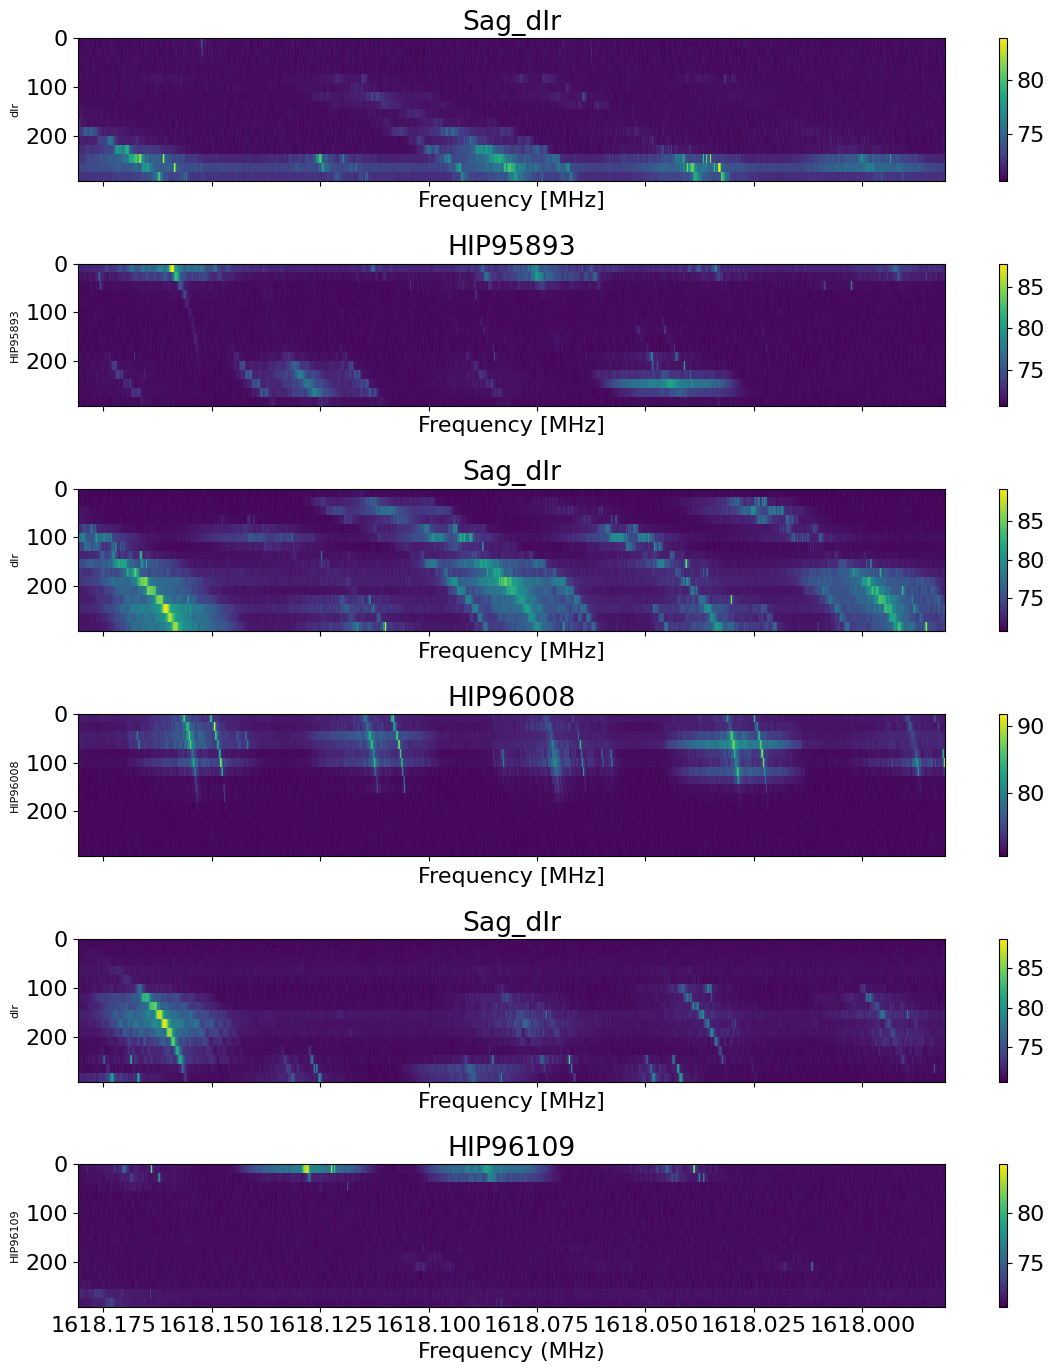

In [52]:
plot_cadence_frequency(
    files,
    center=1618.080878,
    span=0.1,
    outfile="cadence_waterfall_1618.png"
)

Plotting blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000.h5
Plotting blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000.h5
Plotting blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000.h5
Plotting blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000.h5
Plotting blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000.h5
Plotting blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000.h5


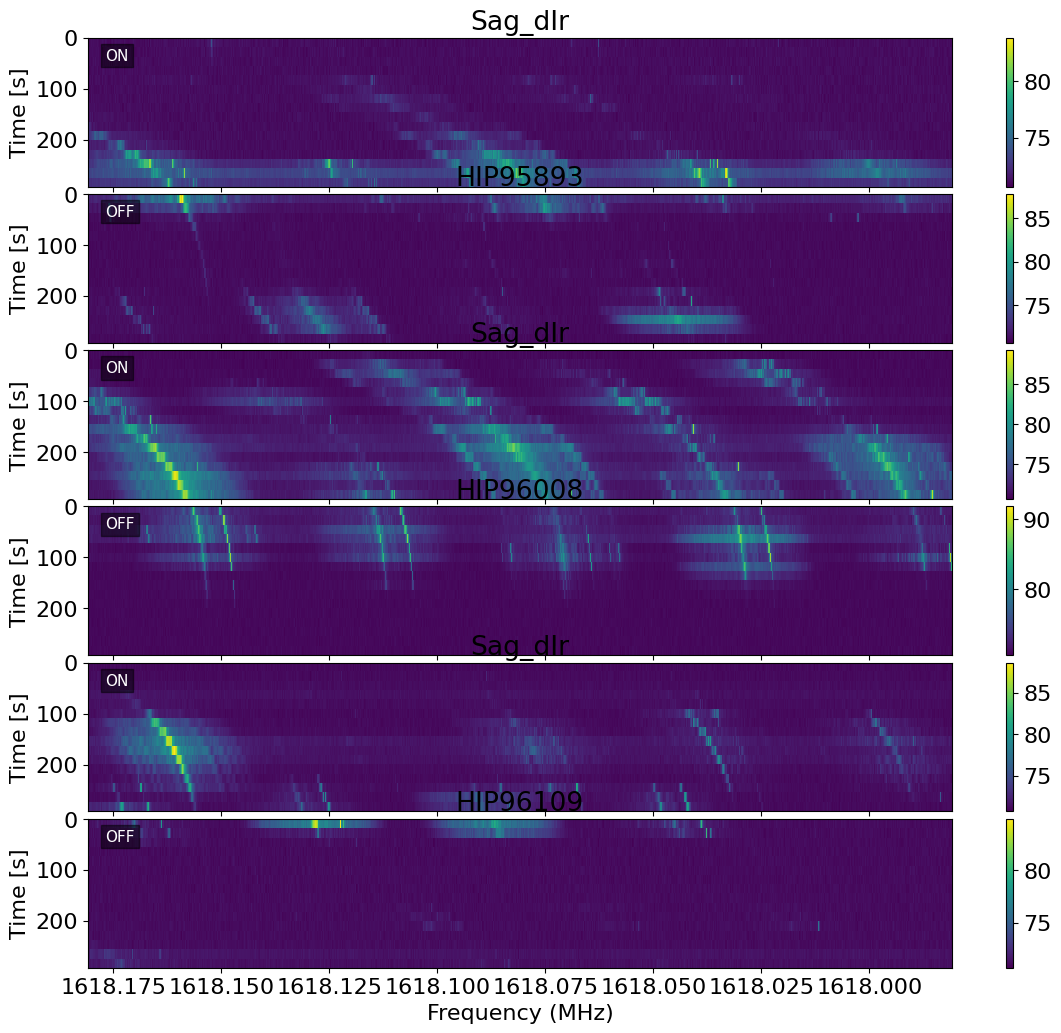

In [53]:
%matplotlib inline

from blimpy import Waterfall
import matplotlib.pyplot as plt
from pathlib import Path


files = [
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_23767_Sag_dIr_0094.rawspec.0000.h5",
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24081_HIP95893_0095.rawspec.0000.h5",
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24396_Sag_dIr_0096.rawspec.0000.h5",
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_24716_HIP96008_0097.rawspec.0000.h5",
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25036_Sag_dIr_0098.rawspec.0000.h5",
    "/datag/pipeline/AGBT21A_996_46/blc03/blc03_guppi_59404_25359_HIP96109_0099.rawspec.0000.h5",
]


center = 1618.080878
span = 0.1   # MHz on each side


fig, axes = plt.subplots(
    len(files),
    1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.05}
)

if len(files) == 1:
    axes = [axes]


for ax, filename in zip(axes, files):

    print(f"Plotting {Path(filename).name}")

    wf = Waterfall(
        filename,
        f_start=center-span,
        f_stop=center+span,
    )

    # plot into current axis
    plt.sca(ax)
    wf.plot_waterfall()

    # Steve convention:
    # time increases downward
    # frequency increases toward left
    ax.invert_yaxis()
    ax.invert_xaxis()


    # Label ON/OFF
    if "Sag" in filename:
        label = "ON"
    else:
        label = "OFF"


    ax.text(
        0.02,
        0.85,
        label,
        transform=ax.transAxes,
        fontsize=11,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.5,
            pad=3
        )
    )


    # remove redundant tick labels
    if ax != axes[-1]:
        ax.set_xlabel("")


axes[-1].set_xlabel("Frequency (MHz)")


plt.subplots_adjust(
    hspace=0.05,
    left=0.08,
    right=0.98,
    top=0.98,
    bottom=0.05
)


plt.savefig(
    "cadence_waterfall_1618MHz_ON_OFF.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()